# Compressible Euler Equations

## Generate Data & Fit Basis

#### Imports & Config

In [30]:
import sys
sys.path.append("../things")
sys.path.append("helpers")
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

%matplotlib inline

import os
import numpy as np
import matplotlib.pyplot as plt
import opinf
import config
import utils
import step1_generate_data as step1
import random
import jax

In [31]:
training_span = (0, 0.08)
num_samples = 250
noiselevel = .03
num_regression_points = 400
numPODmodes = 6
num_pulls = 200
time_domain_test = np.linspace(0, training_span[-1], num_regression_points)
time_domain_eval_training = np.linspace(0, training_span[-1], num_regression_points)
normalization = 1e-6
rng_key = jax.random.PRNGKey(42)

In [32]:
sampler = step1.trajectory(
    training_span,
    num_samples,
    noiselevel,
)
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, noiselevel)

time_domain_eval_prediction = np.linspace(0, time_domain[-1], int(num_regression_points/training_span[-1]*time_domain[-1]))

print(true_states.shape, time_domain_sampled.shape, snapshots_sampled.shape)

generating training data...done in 0.92 s.
generating training data...done in 0.86 s.
(600, 401) (250,) (600, 250)


### Fit Basis

In [33]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

reducing noisy training states to 6 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (600, 250)
(600, 250) (600, 250)
(6, 401)
done in 0.03 s.


## Run Model GP Model and Visualize Results

### Bayesian GP

#### Define and Run Model

In [34]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel

kernel = RBFKernel()

def model(
        time: jnp.array, 
        qhat: jnp.array,
        normalization=1e-8,  # Very small regularization
    ):
    num_time_steps = time.shape[0]
    
    # Get time scale
    time_range = time.max() - time.min()
    
    Ls = []
    Vars = []
    noises = []
    
    for i in range(numPODmodes):
        # Analyze data scale
        data_std = jnp.std(qhat[i])
        
        # For oscillatory data, we need small lengthscales
        # Start with a prior centered at ~1/20th of the time range
        lengthscale = numpyro.sample(f"lengthscale{i}", 
                                     dist.LogNormal(jnp.log(time_range/20), 1.0))
        Ls.append(lengthscale)
        
        # Variance based on data variance
        variance = numpyro.sample(f"variance{i}", 
                                 dist.LogNormal(jnp.log(data_std**2), 0.5))
        Vars.append(variance)
        
        # Small noise since data looks clean
        noise = numpyro.sample(f"noise{i}", 
                              dist.LogNormal(-8.0, 1.0))  # Very small noise
        noises.append(noise)
        
        # Compute kernel matrix
        K = kernel(time, time, lengthscale, variance)
        
        # Add tiny regularization for numerical stability
        K_noise = K + (noise + normalization) * jnp.eye(num_time_steps)
        
        # GP prior
        x = numpyro.sample(f"f{i}", dist.MultivariateNormal(jnp.zeros(num_time_steps), K_noise))
        
        # Likelihood
        with numpyro.plate(f"data{i}", num_time_steps):
            numpyro.sample(f"y{i}", dist.Normal(x, jnp.sqrt(noise)), obs=qhat[i])

Starting SVI optimization...
Iteration 0: loss = 9303.8438
Iteration 100: loss = 3616.8970
Iteration 200: loss = 1759.0790
Iteration 300: loss = 1193.9797
Iteration 400: loss = 939.2990
Iteration 500: loss = 701.5229
Iteration 600: loss = 456.1533
Iteration 700: loss = 171.6030
Iteration 800: loss = -183.3815
Iteration 900: loss = -387.6915
Iteration 1000: loss = -665.8681
Iteration 1100: loss = -965.1145
Iteration 1200: loss = -1204.8550
Iteration 1300: loss = -1487.4535
Iteration 1400: loss = -1695.9430
Iteration 1500: loss = -1927.2606
Iteration 1600: loss = -2069.8179
Iteration 1700: loss = -2215.2771
Iteration 1800: loss = -2387.0588
Iteration 1900: loss = -2525.8445
Iteration 2000: loss = -2620.1328
Iteration 2100: loss = -2796.4092
Iteration 2200: loss = -2882.7168
Iteration 2300: loss = -2825.4548
Iteration 2400: loss = -2938.6621
Iteration 2500: loss = -2984.6829
Iteration 2600: loss = -3060.8044
Iteration 2700: loss = -3142.0139
Iteration 2800: loss = -3170.9421
Iteration 290

<Figure size 640x480 with 0 Axes>

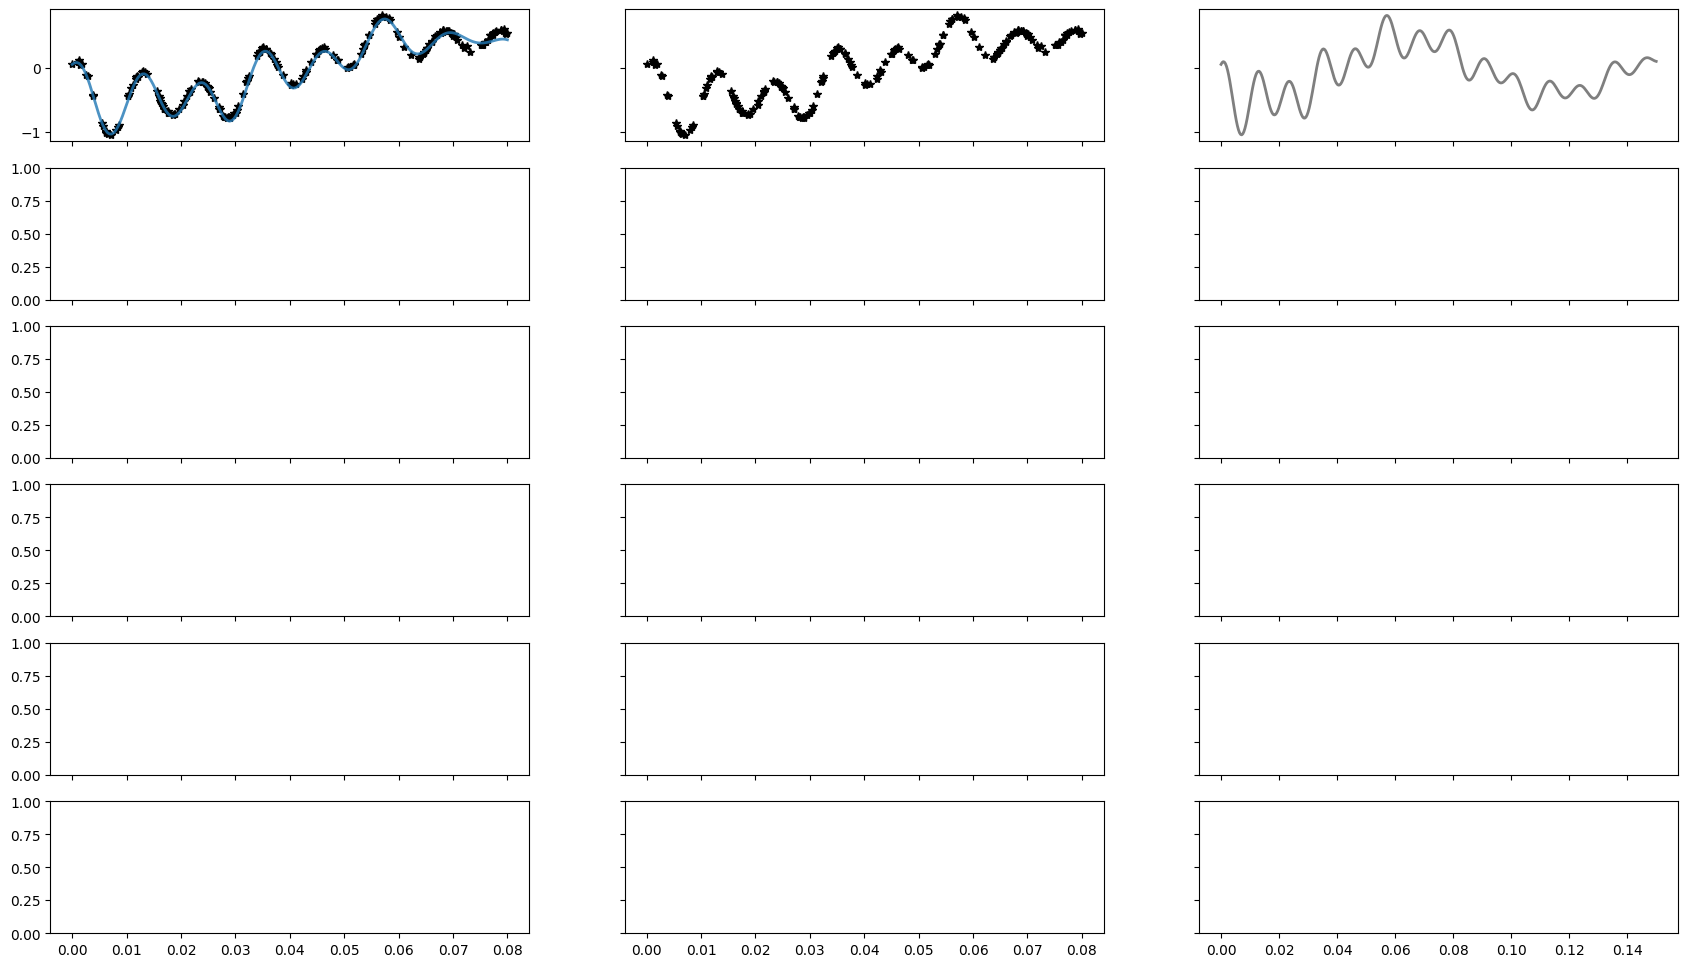

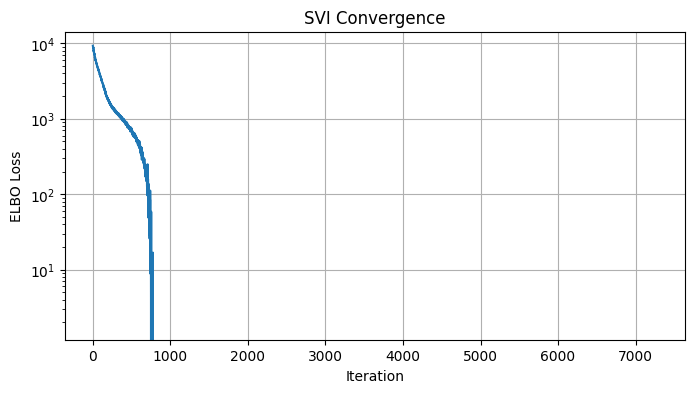

In [35]:
# Create autoguide
guide = autoguide.AutoNormal(model)
optimizer = Adam(step_size=0.01)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

svi_state = svi.init(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     normalization=normalization
                     )

@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_sampled[:, None], 
                                  qhat=snapshots_compressed,
                                  normalization=normalization
                                  )
    return svi_state, loss

num_iterations = 20000
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Rest of your code remains the same...
# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=1000)
gp_samples = predictive(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")


# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

#### Visualize

In [36]:
# Plot posterior samples
import euler_plotter
import importlib
importlib.reload(euler_plotter)

plotter = euler_plotter.EulerPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_prediction=time_domain, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_eval_prediction=time_domain_eval_prediction,
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=full_states_compressed,
            )
plotter.gp_plot_state(
    lengthscales=[gp_samples[f'lengthscale{i}'] for i in range(numPODmodes)],
    variances=[gp_samples[f'variance{i}'] for i in range(numPODmodes)],
    noises=[gp_samples[f'noise{i}'] for i in range(numPODmodes)],
    max_num_samples=250,
    figsize=(18,10)
)
plotter.gp_plot_derivatives()

Number of samples: 250


In [37]:
### Compute mean and std of each thing that we need

Ls_means = np.array([gp_samples[f'lengthscale{i}'].mean() for i in range(numPODmodes)])
Ls_stds = np.array([gp_samples[f'lengthscale{i}'].std() for i in range(numPODmodes)])
Ls_covs = np.array([jnp.cov(gp_samples[f'lengthscale{i}']) for i in range(numPODmodes)])
Vs_means = np.array([gp_samples[f'variance{i}'].mean() for i in range(numPODmodes)])
Vs_stds = np.array([gp_samples[f'variance{i}'].std() for i in range(numPODmodes)])
Vs_covs = np.array([jnp.cov(gp_samples[f'variance{i}']) for i in range(numPODmodes)])
Ns_means = np.array([gp_samples[f'noise{i}'].mean() for i in range(numPODmodes)])
Ns_stds = np.array([gp_samples[f'noise{i}'].std() for i in range(numPODmodes)])
Ns_covs = np.array([jnp.cov(gp_samples[f'noise{i}']) for i in range(numPODmodes)])
Fs_means = np.array([gp_samples[f'f{i}'].mean(axis=0) for i in range(numPODmodes)])

Ls_means.shape, Ls_stds.shape, Ls_covs.shape, Vs_means.shape, Vs_stds.shape, Vs_covs.shape, Ns_means.shape, Ns_stds.shape, Ns_covs.shape, Fs_means.shape

((6,), (6,), (6,), (6,), (6,), (6,), (6,), (6,), (6,), (6, 250))

In [38]:
### Plot gp predictions
from helpers.bgp_jax import BayesianGP

fig, ax = plt.subplots(numPODmodes, 1, figsize = (8,12))


eval_points = [[] for i in range(numPODmodes)] 
eval_stds = [[] for i in range(numPODmodes)] 

for i in range(numPODmodes):
    gp_samples[f'Xi{i}'] = []

for i in range(num_pulls):
    rand_idx = random.randint(0, len(gp_samples['lengthscale0']))
    Ls = np.array([gp_samples[f'lengthscale{i}'][rand_idx] for i in range(numPODmodes)])
    Vs = np.array([gp_samples[f'variance{i}'][rand_idx] for i in range(numPODmodes)])
    Ns = np.array([gp_samples[f'noise{i}'][rand_idx] for i in range(numPODmodes)])

    gp = BayesianGP()
    gp.X_train = time_domain_sampled[:, None]
    for j in range(numPODmodes):
        # fi = gp_samples[f'f{j}'][rand_idx]
        gp.y_train = snapshots_compressed[j]
        mean, std, _ = gp.predict_with_hypers(X_test=time_domain_sampled[:, None], lengthscale=Ls[j], variance=Vs[j], noise=Ns[j])
        mean_test, std_test, _ = gp.predict_with_hypers(X_test=time_domain_test[:, None], lengthscale=Ls[j], variance=Vs[j], noise=Ns[j])
        eval_points[j].append(mean_test)
        eval_stds[j].append(std_test)
        gp_samples[f'Xi{j}'].append(mean_test)

for i in range(numPODmodes):
    gp_samples[f'Xi{i}'] = np.array(gp_samples[f'Xi{i}'])

### Given these latent states how do we compute $\dot{\tilde{x}}$

$[\tilde{x} \quad \dot{\tilde{x}}] \sim \mathcal{N}([0, 0], [[K^{yy} \quad K^{yz}], [K^{zy} \quad K^{zz}]])]$

In [39]:
def flatten_time(t: jnp.ndarray) -> jnp.ndarray:
    """Return t with shape (n,) no matter if (n,), (n,1) or (1,n) was given."""
    return jnp.ravel(t)

def rbf_eval(lengthscale: float, variance: float, t: jnp.ndarray, t2: jnp.ndarray) -> jnp.ndarray:
    """Full n×n RBF kernel matrix K_ij = variance * exp(-(t_i-t_j)^2 / (2*ell^2))."""
    t = flatten_time(t)
    t2 = flatten_time(t2)
    diff = t[:, None] - t2[None, :]
    ell2 = lengthscale ** 2
    return variance * jnp.exp(-diff**2 / (2.0 * ell2))

In [40]:
def joint_gp_derivatives(Ls, Vs, time1, time2):
    K_yys = []
    K_zys = []
    K_zzs = []
    for i in range(numPODmodes):
        ell2 = Ls[i]**2
        
        # Standard RBF kernels
        rbf_yy = rbf_eval(Ls[i], Vs[i], time1, time1) 
        rbf_zy = rbf_eval(Ls[i], Vs[i], time2, time1)
        rbf_zz = rbf_eval(Ls[i], Vs[i], time2, time2)
        
        # K_yy with noise term
        K_yy = rbf_yy + 1e-5 * np.eye(len(time1))  # Fixed: use eye instead of diag
        
        # K_zy: derivative kernel - note the correct difference computation
        diff_zy = time2[:, None] - time1[None, :]  # (250, 150)
        K_zy = -(diff_zy / ell2) * rbf_zy  # (250, 150)
        
        # K_zz: second derivative kernel
        diff_zz = time2[:, None] - time2[None, :]  # (250, 250)
        K_zz = ((1 - (diff_zz**2 / ell2)) / ell2) * rbf_zz  # (250, 250)
        
        K_yys.append(K_yy)
        K_zys.append(K_zy)
        K_zzs.append(K_zz)

    # Now the prediction should work
    mu_z = []
    cov_z = []
    for i in range(numPODmodes):
        w = jnp.linalg.solve(K_yys[i], snapshots_compressed[i])  # w shape: (150,)
        mu_zi = K_zys[i] @ w  # (250, 150) @ (150,) = (250,)
        mu_z.append(mu_zi)

        cov_zi = K_zzs[i] - K_zys[i] @ jnp.linalg.solve(K_yys[i], K_zys[i].T)
        cov_z.append(cov_zi)

    return jnp.array(mu_z), jnp.array(cov_z)  # Shape should be (6, 250)

In [41]:
from jax.scipy.special import gammaln
import jax.numpy as jnp

def binom(x, y):
  return jnp.exp(gammaln(x + 1) - gammaln(y + 1) - gammaln(x - y + 1))

def Quadraticckron(state):
    return jnp.concatenate(
                [state[i] * state[: i + 1] for i in range(state.shape[0])],
                axis=0,
            )

def Cubicckron(state):
    state2 = Quadraticckron(state)
    lens = binom(jnp.arange(2, len(state) + 2), 2).astype(int)
    return jnp.concatenate(
        [state[i] * state2[: lens[i]] for i in range(state.shape[0])],
        axis=0,
    )

def khatri_rao(a, b):
    return jnp.vstack([jnp.kron(a[:, k], b[:, k]) for k in range(b.shape[1])]).T

class JaxCompatibleModel(opinf.models.ContinuousModel):
    def __init__(self, operators, solver=None, *args, **kwargs):
        super().__init__(operators, solver, *args, **kwargs)
    
    def _assemble_data_matrix(self, states, inputs):
        """Assemble the data matrix for operator inference."""
        blocks = []
        for i in self._indices_of_operators_to_infer:
            op = self.operators[i]
            if isinstance(op, opinf.operators.ConstantOperator):
                block = jnp.ones((1, jnp.atleast_1d(states).shape[-1]))
            elif isinstance(op, opinf.operators.LinearOperator):
                block = jnp.atleast_2d(states)
            elif isinstance(op, opinf.operators.QuadraticOperator):
                block = Quadraticckron(jnp.atleast_2d(states))
            elif isinstance(op, opinf.operators.CubicOperator):
                block =Cubicckron(np.atleast_2d(states))
            elif isinstance(op, opinf.operators.InputOperator):
                block =jnp.atleast_2d(inputs)
            elif isinstance(op, opinf.operators.StateInputOperator):
                block =khatri_rao(jnp.atleast_2d(inputs), jnp.atleast_2d(states))
            else:
                print("idkK!!", type(op))
            blocks.append(block.T)

        return jnp.hstack(blocks)

(600, 250) (600, 250)


<Figure size 640x480 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

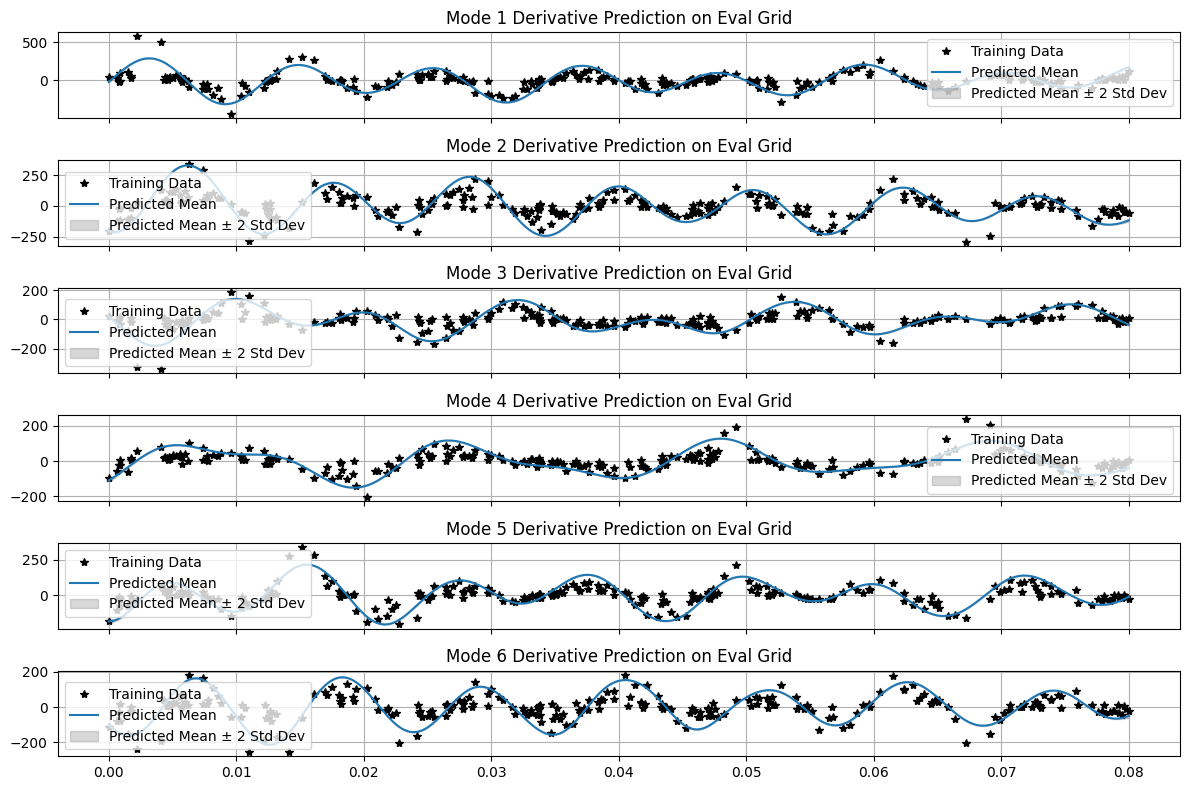

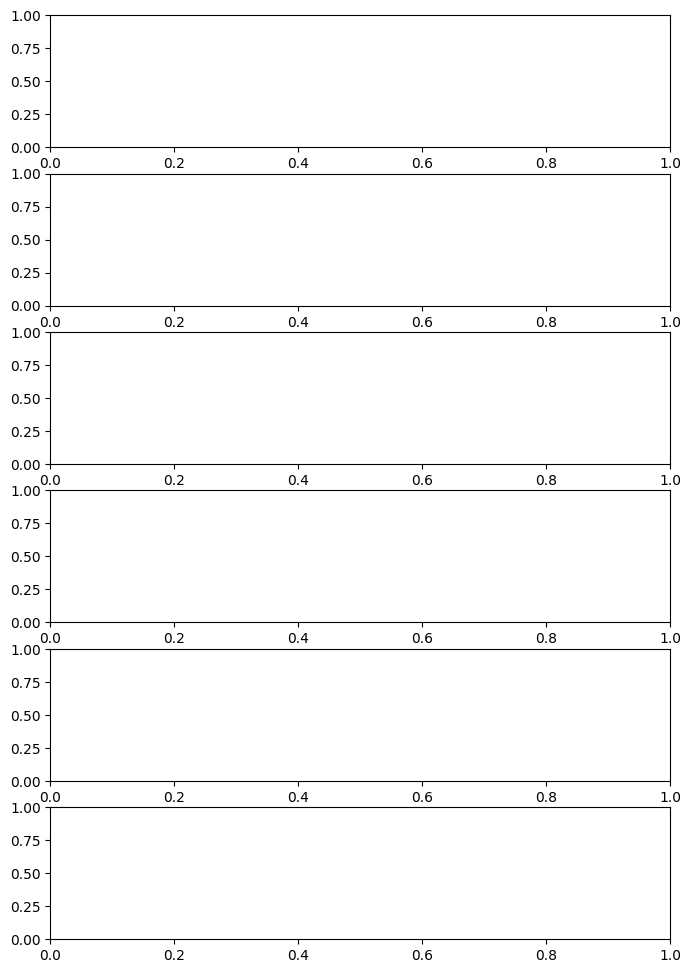

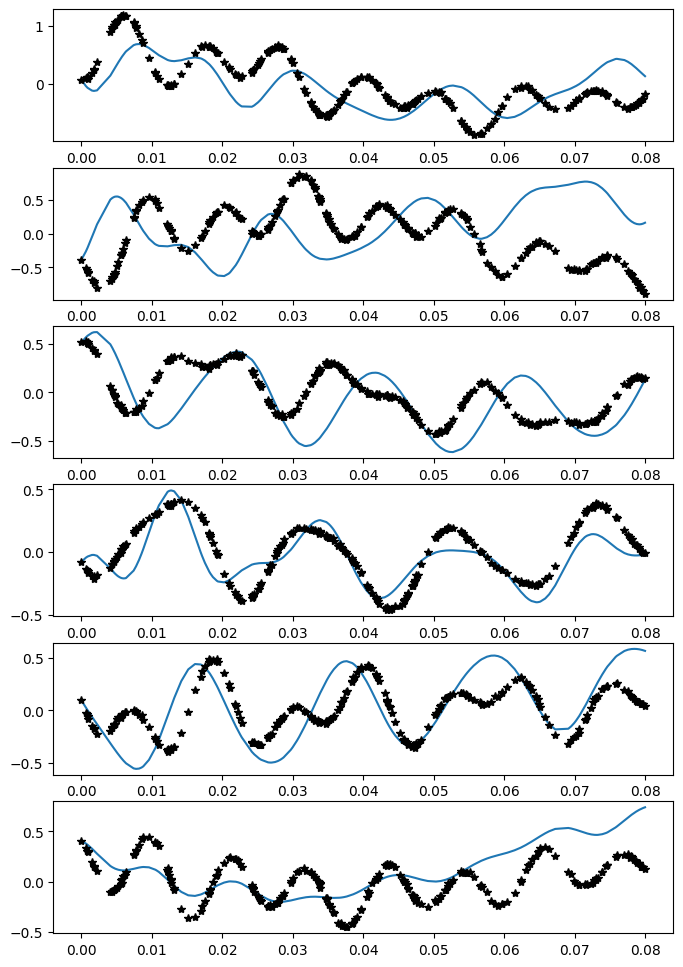

In [42]:
import numpy as np
import random
import time
import opinf

rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
    # model=opinf.models.ContinuousModel(
    #     operators="cAH",
    #     solver=opinf.lstsq.L2Solver(regularizer=1e-4),
    model=JaxCompatibleModel(
        operators='cAH',
        solver=opinf.lstsq.L2Solver(regularizer=1e-2),
    )
).fit(states=snapshots_sampled)

# Solve the ROM over a specified time domain. Make sure it's stable!
Q_rom = rom.predict(snapshots_sampled[:, 0], time_domain)

loaded_operator = np.load("operator.npy")
rom.model._extract_operators(loaded_operator)

# Plot predictions within training time domains
deter_pred = rom.model.predict(
    state0=snapshots_compressed[:, 0], 
    t=time_domain_sampled, 
)
deter_sol = rom.model.predict_result_


fig, ax = plt.subplots(numPODmodes,1, figsize = (8, 12))

for i in range(numPODmodes):
    ax[i].plot(deter_sol.t, deter_sol.y[i])
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')

plt.show()

In [43]:
Xs_means = np.stack(
    [gp_samples[f'Xi{i}'].mean(axis=0) for i in range(numPODmodes)],
    axis=0
)
Xs_covs = np.stack(
    [np.cov(gp_samples[f'Xi{i}'].T) for i in range(numPODmodes)],
    axis=0
)

def stable_cholesky(A, jitter=1e-6):
    """Compute Cholesky with automatic jitter for stability"""
    max_tries = 5
    for i in range(max_tries):
        try:
            L = jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))
            return L
        except:
            jitter *= 10
    return jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))

def stable_solve(A, b, jitter=1e-6):
    """Solve linear system with regularization"""
    return jnp.linalg.solve(A + jitter * jnp.eye(A.shape[0]), b)

In [138]:
import jax.numpy as jnp
import numpyro.distributions as dist
from jax.scipy.linalg import kron

class MatrixNormal(dist.Distribution):
    arg_constraints = {}
    support = dist.constraints.real
    reparametrized_params = ["loc", "rowcov", "colcov"]

    def __init__(self, loc, rowcov, colcov, validate_args=None):
        """
        loc: mean matrix (m x n)
        rowcov: row covariance (m x m)
        colcov: column covariance (n x n)
        """
        self.loc = jnp.asarray(loc)
        self.rowcov = jnp.asarray(rowcov)
        self.colcov = jnp.asarray(colcov)

        m, n = self.loc.shape
        cov = kron(self.colcov, self.rowcov)   # (mn x mn) covariance
        mean = self.loc.flatten()

        self._mvn = dist.MultivariateNormal(mean, covariance_matrix=cov)

        super().__init__(batch_shape=(), event_shape=self.loc.shape,
                         validate_args=validate_args)

    def sample(self, key, sample_shape=()):
        vec_sample = self._mvn.sample(key, sample_shape)
        return vec_sample.reshape(sample_shape + self.loc.shape)

    def log_prob(self, value):
        vec_value = value.reshape(-1)
        return self._mvn.log_prob(vec_value)

ImportError: cannot import name 'kron' from 'jax.scipy.linalg' (/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/jax/scipy/linalg.py)

In [278]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

kernel = RBFKernel()


def model(time, normalization=1e-6):
    num_time_steps = time.shape[0]
    gamma = 1e1 #4e2, 1e0

    min_std = 2e1   # lower bound
    factor  = 0.5   # scaling factor

    # O = numpyro.sample(
    #     "O",
    #     dist.Normal(
    #         loc=loaded_operator,
    #         scale=jnp.maximum(min_std, factor * jnp.abs(loaded_operator))
    #     )
    # )

    O = numpyro.sample(
        "O",
        dist.Normal(
            loc=jnp.zeros_like(loaded_operator),
            scale=gamma * jnp.ones_like(loaded_operator)
        )
    )

    Xs = []
    Ls = []
    Vars = []
    noises = []
    Kyys = []
    
    for i in range(numPODmodes):
        lengthscale = Ls_means[i]
        Ls.append(lengthscale)

        variance = Vs_means[i]
        Vars.append(variance)

        noise = Ns_means[i]
        noises.append(noise)

        Kyy = get_c_phi(lengthscale, variance, time, normalization)
        Kyys.append(Kyy)

        Xs.append(
            numpyro.sample(
                f"X{i}",
                dist.MultivariateNormal(loc=Xs_means[i], covariance_matrix=Xs_covs[i]+normalization*jnp.eye(Xs_covs[i].shape[0])),
            )
        )
        
    f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs=None) @ O.T

    mu_z, cov_z = joint_gp_derivatives(Ls, Vars, time_domain_sampled, time)
    
    for i in range(numPODmodes):
        mu_zi = mu_z[i]
        cov_zi = cov_z[i]
        constraint_cov = cov_zi + gamma * jnp.eye(num_time_steps)

        numpyro.sample(
            f'ode_constraint{i}',
            dist.MultivariateNormal(mu_zi, constraint_cov),
            obs=f_Xi_ohat.T[i]
        )

Starting SVI optimization...
Iteration 0: loss = 950693.0000
Iteration 100: loss = 830145.9375
Iteration 200: loss = 731452.4375
Iteration 300: loss = 647288.9375
Iteration 400: loss = 574302.7500
Iteration 500: loss = 510620.9375
Iteration 600: loss = 454847.4375
Iteration 700: loss = 405845.4375
Iteration 800: loss = 362660.1250
Iteration 900: loss = 324480.9375
Iteration 1000: loss = 290619.6250
Iteration 1100: loss = 260492.8125
Iteration 1200: loss = 233607.6250
Iteration 1300: loss = 209548.0000
Iteration 1400: loss = 187963.6719
Iteration 1500: loss = 168559.4688
Iteration 1600: loss = 151087.0000
Iteration 1700: loss = 135380.1562
Iteration 1800: loss = 122013.1250
Iteration 1900: loss = 113126.0000
Iteration 2000: loss = 104827.8750
Iteration 2100: loss = 94855.4766
Iteration 2200: loss = 85490.0859
Iteration 2300: loss = 76876.5625
Iteration 2400: loss = 69451.1016
Iteration 2500: loss = 61219.5977
Iteration 2600: loss = 56391.4961
Iteration 2700: loss = 51269.2305
Iteration 

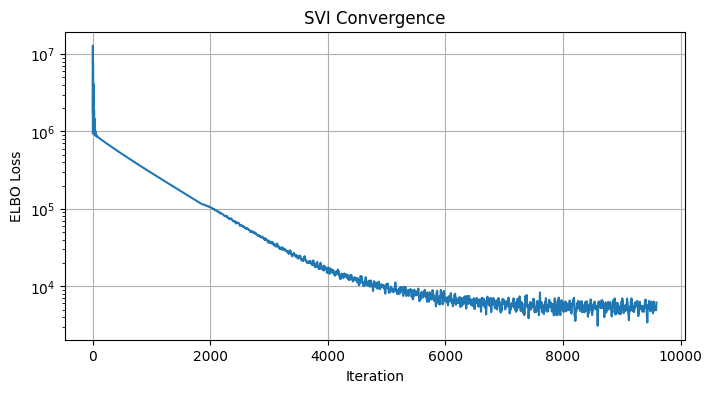

In [286]:
guide = autoguide.AutoDelta(model)

normalization = 1e-6

optimizer = Adam(step_size=0.1)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

svi_state = svi.init(rng_key,
                     time=time_domain_eval_training, 
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_eval_training, 
                                  normalization=normalization
                                  )
    return svi_state, loss

num_iterations = 100000
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if (patience_counter > patience and i > 5000):
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=1000)
gm_samples = predictive(rng_key,
                     time=time_domain_eval_training, 
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

In [287]:
from numpyro.infer import MCMC, NUTS, init_to_value
from numpyro.diagnostics import summary
import jax.numpy as jnp
import numpyro.distributions as dist
import numpyro

# Get initial values from your SVI/guide samples
Omean = gm_samples['O'].mean(axis=0)
Ostd = gm_samples['O'].std(axis=0)
num_chains = 1
numpyro.set_host_device_count(num_chains)

def reparameterized_mcmc_model(time, gamma=5e-2, normalization=1e-6):
    """
    Reparameterized MCMC model using standardized coordinates.
    This reduces correlations between parameters and improves geometry.
    """
    num_time_steps = time.shape[0]
    
    # === REPARAMETERIZE O ===
    # Instead of sampling O directly, sample a standardized version
    # min_relative_std = 0.05
    min_relative_std = 0.1
    min_absolute_std = 1.0
    O_uncertainty = jnp.maximum(Ostd, jnp.maximum(min_relative_std * jnp.abs(Omean), min_absolute_std))
    
    # Sample standardized O (zero mean, unit variance)
    O_standardized = numpyro.sample('O_standardized', 
                                    dist.Normal(jnp.zeros_like(Omean), 
                                               jnp.ones_like(Omean)))
    
    # Deterministically transform to actual O
    # This makes O = Omean + O_uncertainty * O_standardized
    O = numpyro.deterministic('O', Omean + O_uncertainty * O_standardized)
    
    # === REPARAMETERIZE X VARIABLES ===
    Xs = []
    Xs_standardized = []
    for i in range(numPODmodes):
        # Compute Cholesky decomposition for numerical stability
        X_cov = Xs_covs[i] + normalization * jnp.eye(Xs_covs[i].shape[0])
        
        # Use Cholesky factorization for more stable sampling
        try:
            L = jnp.linalg.cholesky(X_cov)
        except:
            # If Cholesky fails, add more regularization
            X_cov = Xs_covs[i] + (normalization * 10) * jnp.eye(Xs_covs[i].shape[0])
            L = jnp.linalg.cholesky(X_cov)
        
        # Sample standardized X (zero mean, unit variance)
        X_std = numpyro.sample(
            f"X{i}_standardized",
            dist.Normal(jnp.zeros_like(Xs_means[i]), jnp.ones_like(Xs_means[i]))
        )
        Xs_standardized.append(X_std)
        
        # Transform to actual X using Cholesky factor
        X = numpyro.deterministic(f"X{i}", Xs_means[i] + L @ X_std)
        Xs.append(X)
    
    # === MODEL LIKELIHOOD (unchanged) ===
    f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs=None) @ O.T
    mu_z, cov_z = joint_gp_derivatives(Ls_means, Vs_means, time_domain_sampled, time)
    
    for i in range(numPODmodes):
        mu_zi = mu_z[i]
        cov_zi = cov_z[i]
        constraint_cov = cov_zi + gamma * jnp.eye(num_time_steps)
        
        numpyro.sample(
            f'ode_constraint{i}',
            dist.MultivariateNormal(mu_zi, constraint_cov),
            obs=f_Xi_ohat.T[i]
        )

# === INITIALIZE WITH GOOD VALUES ===
# Convert your MAP estimates to standardized space for initialization
init_values_standardized = {
    'O_standardized': jnp.zeros_like(Omean),  # Start at the mean
}

# # Initialize X in standardized space
# for i in range(numPODmodes):
#     if f'X{i}' in gm_samples:
#         # If you have samples, convert them to standardized space
#         X_cov = Xs_covs[i] + normalization * jnp.eye(Xs_covs[i].shape[0])
#         try:
#             L = jnp.linalg.cholesky(X_cov)
#             L_inv = jnp.linalg.inv(L)
#             X_centered = gm_samples[f'X{i}'].mean(axis=0) - Xs_means[i]
#             init_values_standardized[f'X{i}_standardized'] = L_inv @ X_centered
#         except:
#             init_values_standardized[f'X{i}_standardized'] = jnp.zeros_like(Xs_means[i])
#     else:
#         init_values_standardized[f'X{i}_standardized'] = jnp.zeros_like(Xs_means[i])

# === CONFIGURE STRUCTURED MASS MATRIX ===
# Group correlated parameters together
dense_mass_blocks = [
    ("O_standardized",),  # O parameters are correlated within themselves
    tuple([f"X{i}_standardized" for i in range(numPODmodes)])  # X parameters likely correlated
]

# === RUN MCMC WITH IMPROVED SETTINGS ===
print("Running MCMC with reparameterized model...")
nuts_kernel = NUTS(
    reparameterized_mcmc_model,
    init_strategy=init_to_value(values=init_values_standardized),
    # dense_mass=dense_mass_blocks,  # Use structured mass matrix
    max_tree_depth=12,  # Increase from default 10
    # target_accept_prob=0.9,  # Increase for better exploration in difficult geometries
)

mcmc = MCMC(
    nuts_kernel,
    num_warmup=150,  # Increase warm-up for better adaptation
    num_samples=200,
    num_chains=num_chains,
    chain_method='parallel',
    progress_bar=True,
)

# Run with moderate gamma first
mcmc.run(
    rng_key,
    time=time_domain_eval_training,
    gamma=1e0,  # You can adjust this
    normalization=normalization,
)

Running MCMC with reparameterized model...


sample: 100%|██████████| 350/350 [01:13<00:00,  4.73it/s, 31 steps of size 1.27e-01. acc. prob=0.89] 


In [288]:
# === CHECK DIAGNOSTICS ===
def print_diagnostics(mcmc):
    """Print detailed diagnostics for each parameter"""
    samples = mcmc.get_samples(group_by_chain=True)
    summary_dict = summary(samples)
    
    print("\n" + "="*60)
    print("MCMC Diagnostics Summary")
    print("="*60)
    
    # Separate standardized and deterministic variables
    standardized_params = []
    deterministic_params = []
    constraint_params = []
    
    for param in summary_dict.keys():
        if '_standardized' in param:
            standardized_params.append(param)
        elif 'ode_constraint' in param:
            constraint_params.append(param)
        else:
            deterministic_params.append(param)
    
    # Print standardized parameters (these are what we actually sample)
    if standardized_params:
        print("\n📊 Standardized Parameters (key for convergence):")
        print("-" * 50)
        for param in sorted(standardized_params):
            stats = summary_dict[param]
            max_rhat = jnp.max(stats["r_hat"])
            min_ess = jnp.min(stats["n_eff"])
            
            if max_rhat > 1.01:
                status = "⚠️ "
            else:
                status = "✅"
            
            print(f"{status} {param:30s} r_hat={max_rhat:.4f}, min_ESS={min_ess:.0f}")
    
    # Print deterministic transformations
    if deterministic_params:
        print("\n📈 Transformed Parameters:")
        print("-" * 50)
        for param in sorted(deterministic_params):
            stats = summary_dict[param]
            max_rhat = jnp.max(stats["r_hat"])
            print(f"   {param:30s} r_hat={max_rhat:.4f}")
    
    # Check for problems
    problem_params = [p for p, s in summary_dict.items() 
                     if jnp.max(s["r_hat"]) > 1.01 and '_standardized' in p]
    
    if problem_params:
        print(f"\n⚠️  Warning: {len(problem_params)} parameters have r_hat > 1.01")
        print("Consider:")
        print("  1. Increasing num_warmup and num_samples")
        print("  2. Adjusting gamma (try values between 1e-2 and 1e-1)")
        print("  3. Checking if normalization needs adjustment")
    else:
        print("\n✅ All parameters have converged well (r_hat ≤ 1.01)")
    
    return summary_dict

# Print diagnostics
diagnostics = print_diagnostics(mcmc)

# Get the final samples
samples = mcmc.get_samples()
print(f"\nSampling complete. Retrieved {len(samples['O'])} samples.")


MCMC Diagnostics Summary

📊 Standardized Parameters (key for convergence):
--------------------------------------------------
⚠️  O_standardized                 r_hat=1.0960, min_ESS=37
⚠️  X0_standardized                r_hat=1.0435, min_ESS=43
⚠️  X1_standardized                r_hat=1.0564, min_ESS=38
⚠️  X2_standardized                r_hat=1.0613, min_ESS=30
⚠️  X3_standardized                r_hat=1.0684, min_ESS=18
⚠️  X4_standardized                r_hat=1.1347, min_ESS=27
⚠️  X5_standardized                r_hat=1.0945, min_ESS=-3782

📈 Transformed Parameters:
--------------------------------------------------
   O                              r_hat=1.0960
   X0                             r_hat=1.0434
   X1                             r_hat=1.0516
   X2                             r_hat=1.0500
   X3                             r_hat=1.0562
   X4                             r_hat=1.1495
   X5                             r_hat=1.0914

⚠️  Warning: 7 parameters have r_hat > 1.0

### Generate Predictions, Means, Medians and Percentiles via samples

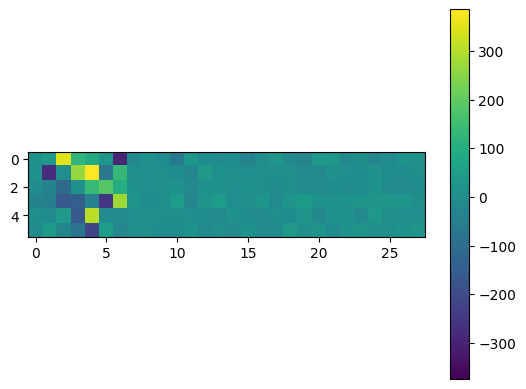

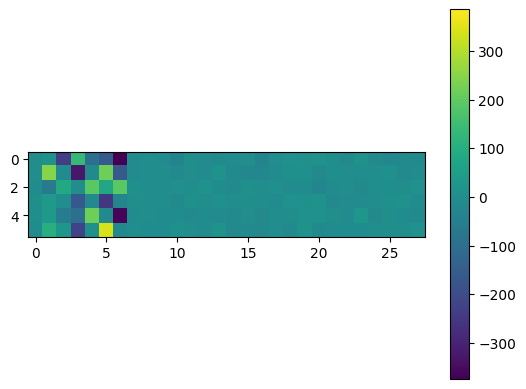

In [289]:
Os = []
Xs = []
rom_solves = []

for i in range(num_pulls):
    O = samples['O'][i]
    Os.append(O)
    Xs.append(np.array([samples[f'X{j}'][i] for j in range(numPODmodes)]))

    rom.model._extract_operators(np.array(O))
    rom.model.predict(state0=snapshots_compressed[:, 0], t=time_domain_eval_training)
    if rom.model.predict_result_.y.shape[1] < time_domain_eval_training.size:
        print("Bad solve, skipping", rom.model.predict_result_.y.shape)
        continue
    rom_solves.append(rom.model.predict_result_.y)

Xs = np.array(Xs)
Os = np.array(Os)
rom_solves = np.array(rom_solves)


X_mean = Xs.mean(axis=0)
O_mean = Os.mean(axis=0)

plt.imshow(loaded_operator, vmin = min(loaded_operator.min(), O_mean.min()), vmax = max(loaded_operator.max(), O_mean.max()))
plt.colorbar()
plt.show()
plt.imshow(O_mean, vmin = min(O_mean.min(), loaded_operator.min()), vmax = max(O_mean.max(), loaded_operator.max()))
plt.colorbar()
plt.show()

rom_solves_mean = rom_solves.mean(axis=0)
X_median = np.median(Xs, axis=0)
O_median = np.median(Os, axis=0)
rom_solves_median = np.median(rom_solves, axis=0)
rom_solves_95 = np.percentile(rom_solves, 99, axis=0)
rom_solves_5 = np.percentile(rom_solves, 1, axis=0)


In [292]:
# Plot posterior samples
import euler_plotter
import importlib
importlib.reload(euler_plotter)

plotter = euler_plotter.EulerPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_prediction=time_domain, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_eval_prediction=time_domain_eval_prediction,
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=full_states_compressed,
            )

plotter.operator_plot(
                    operator_samples=samples['O'],
                    latent_state_samples=[samples[f'X{i}'] for i in range(numPODmodes)],
                    rom=rom,
                    figsize=(21, 12),
                    max_num_samples=1000
)

(200, 6, 28) (200, 6, 400)
(200, 6, 400) (200, 6, 750)


<Figure size 640x480 with 0 Axes>

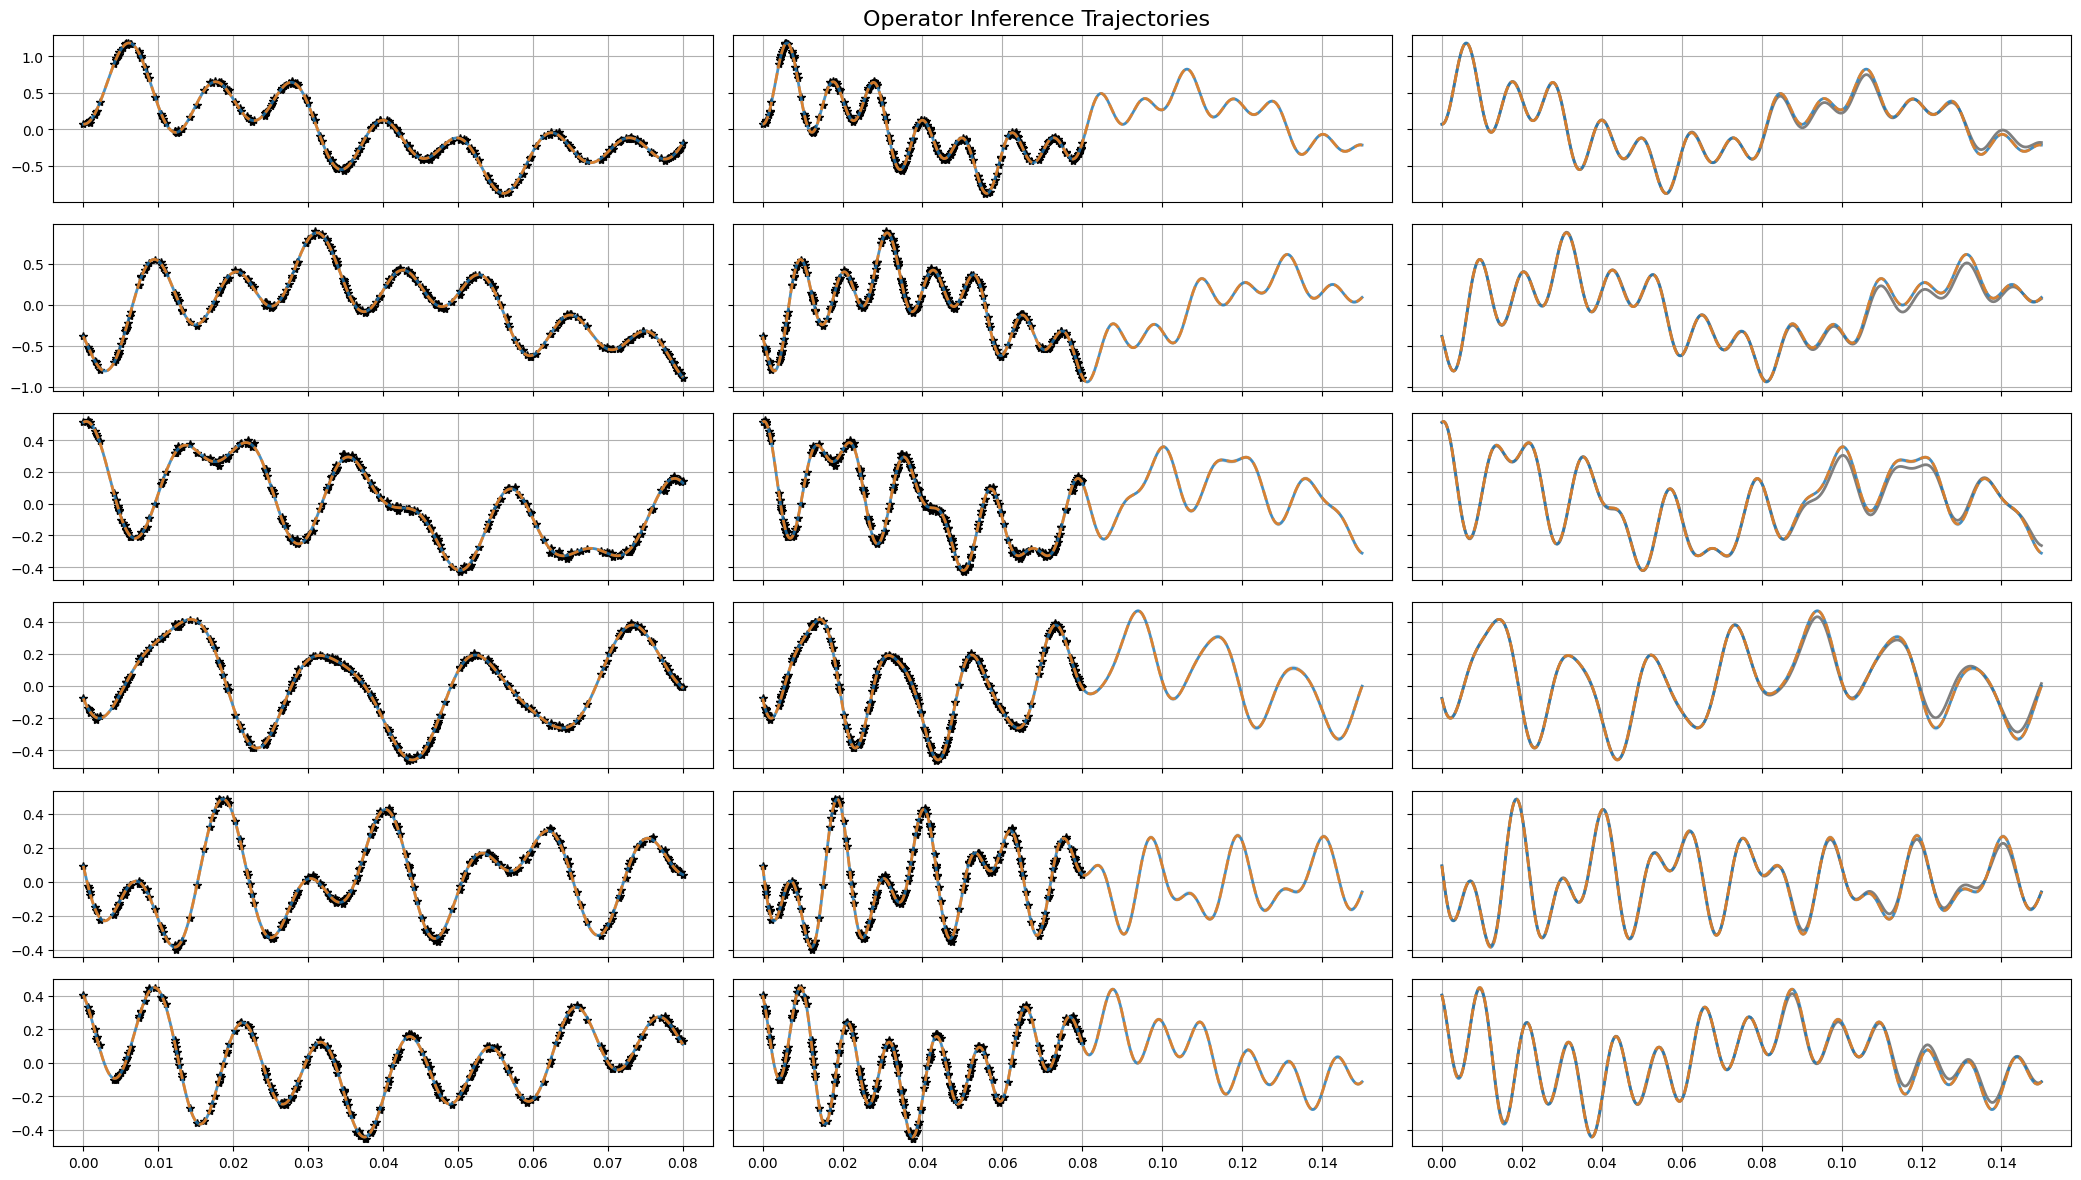

In [293]:
plt.show()